# 05 · What to control for — and what NOT to (pathmc)

**The decision.** Which variables go in the model? This silently biases everything above it.
Throw in "every column we have" and you'll control for **mediators** (removing the effect you
wanted) and **colliders** (inventing an effect that isn't there); leave out a real **confounder**
and you keep the bias. This is the "how did we know what to control for?" slide — the one that
makes a skeptical CMO trust the rest.

We (a) build a **gallery** of the four canonical structures and the correct action for each,
(b) let `pathmc` read the DAG and enumerate the admissible adjustment set + flag colliders,
(c) demonstrate the bias of each wrong choice **in euros**, and (d) bound the residual risk from
an *unobserved* confounder with a sensitivity contour and an **E-value**.

7-step contract, with identification (not estimation) as the whole point.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, estimators as est, metrics, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 17

## 1b · The four structures — a control-or-not gallery

Every "should I control for W?" question reduces to *what role W plays* between treatment T and
outcome Y:


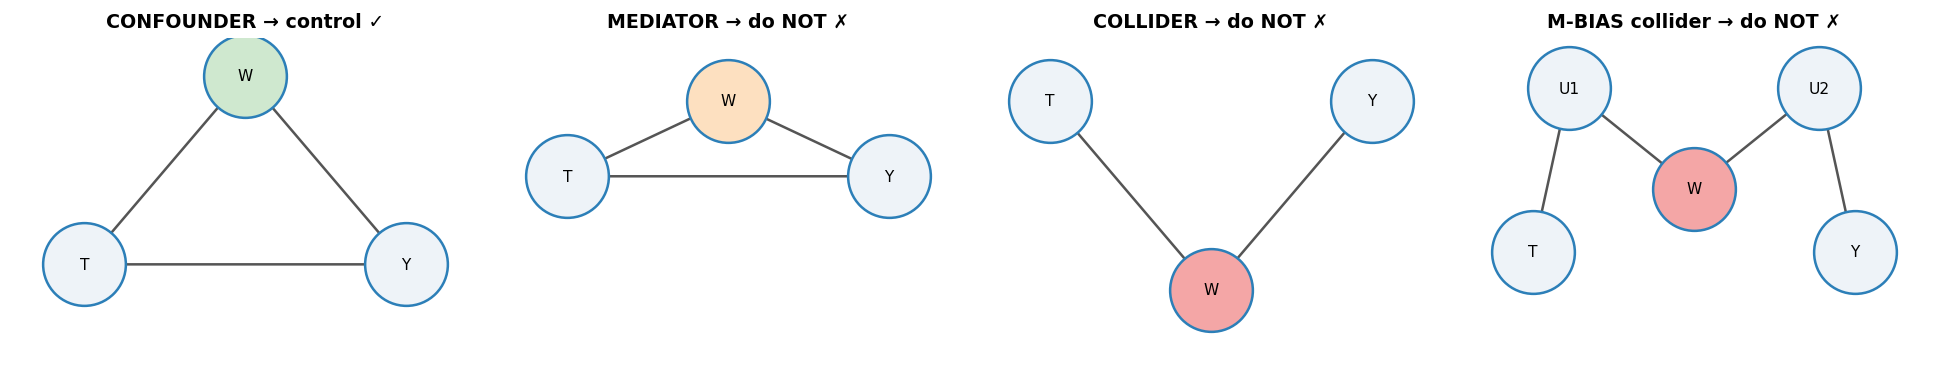

In [2]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.0))
plots.draw_dag(ax[0], {"W":(0.5,1.0),"T":(0.05,0.25),"Y":(0.95,0.25)},
    [("W","T"),("W","Y"),("T","Y")], node_colors={"W":"#cfe8cf"}, title="CONFOUNDER → control ✓")
plots.draw_dag(ax[1], {"T":(0.05,0.6),"W":(0.5,0.9),"Y":(0.95,0.6)},
    [("T","W"),("W","Y"),("T","Y")], node_colors={"W":"#fde0c0"}, title="MEDIATOR → do NOT ✗")
plots.draw_dag(ax[2], {"T":(0.05,0.9),"Y":(0.95,0.9),"W":(0.5,0.15)},
    [("T","W"),("Y","W")], node_colors={"W":"#f4a6a6"}, title="COLLIDER → do NOT ✗")
plots.draw_dag(ax[3], {"U1":(0.15,0.95),"U2":(0.85,0.95),"T":(0.05,0.3),"Y":(0.95,0.3),"W":(0.5,0.55)},
    [("U1","T"),("U1","W"),("U2","W"),("U2","Y")], node_colors={"W":"#f4a6a6"}, title="M-BIAS collider → do NOT ✗")
fig.tight_layout()

- **Confounder** (common cause of T and Y): **control** — it opens a backdoor path.
- **Mediator** (on the causal path T→W→Y): **do not** — you'd remove part of the effect you want.
- **Collider** (common effect of T and Y): **do not** — conditioning *opens* a spurious path.
- **M-bias collider** (pre-treatment, common effect of two latents that separately cause T and Y):
  **do not** — even a *pre-treatment* variable can be a trap. "Adjust for everything pre-treatment"
  is wrong.


## 2 · Simulate a ground truth

`email → spend` with a **true effect of €6**. Around it: **`loyalty`** is a **confounder**
(drives both email and spend → must control); **`responded`** is a **collider** (caused by both
email and spend → tempting but poisonous); **`opened_email`** is a post-treatment descendant.


In [3]:
df, true_ate = dgp.dag_control_demo(n=2000, seed=SEED)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")
df.head()

TRUE effect of email on spend = €6.0


,email,loyalty,opened_email,responded,spend
0,1.0,1.101262,1.0,0.0,27.705363
1,0.0,0.338431,0.0,0.0,17.425501
2,0.0,-0.539972,0.0,0.0,9.602566
3,0.0,-1.260242,0.0,0.0,5.056443
4,1.0,-1.894621,0.0,0.0,7.175152


## 3 · Identify — let the DAG choose the adjustment set

The **backdoor criterion**: an admissible set $Z$ blocks every backdoor path T→Y and contains no
descendant of T. `pathmc` enumerates admissible sets and flags colliders straight from the graph
— **no data needed**, because identification is about structure, not numbers.


In [4]:
spec = '''
email        ~ b1*loyalty
opened_email ~ b2*email
responded    ~ b3*email + b4*spend
spend        ~ b5*email + b6*loyalty
'''
m = pathmc.model(spec, data=df)
print("Admissible adjustment set(s) for email → spend:", m.adjustment_sets("email", "spend"))
print("Identifiable:", m.is_identifiable("email", "spend"))
print()
for cand in [{"loyalty"}, {"loyalty","responded"}, {"loyalty","opened_email"}, set()]:
    warns = m.collider_warnings(cand, "email", "spend")
    print(f"control for {cand or '{}'}:  " + ("; ".join(warns) if warns else "OK — no collider opened"))

Admissible adjustment set(s) for email → spend: [{'loyalty'}]
Identifiable: True

control for {'loyalty'}:  OK — no collider opened
control for {'responded', 'loyalty'}:  'responded' is a collider between 'email' and 'spend'. Conditioning on it may open a spurious path and introduce bias.
control for {'opened_email', 'loyalty'}:  OK — no collider opened
control for {}:  OK — no collider opened


## 4–5 · Estimate & Validate — every control choice, in €

We fit the email→spend effect under five control choices and compare to the true €6. Only the
DAG-endorsed set (`{loyalty}`) recovers it; the others are biased, and **the sign of the bias is
predictable from the structure** — omitting the confounder biases *up*, conditioning on a
collider or post-treatment variable biases in the direction of the induced association.


naive (nothing)            € 9.45   (error +3.45)
{loyalty} ✓                € 6.09   (error +0.09)
{loyalty,responded} ✗      € 5.58   (error -0.42)
{loyalty,opened} ✗         € 5.45   (error -0.55)
everything ✗               € 4.97   (error -1.03)


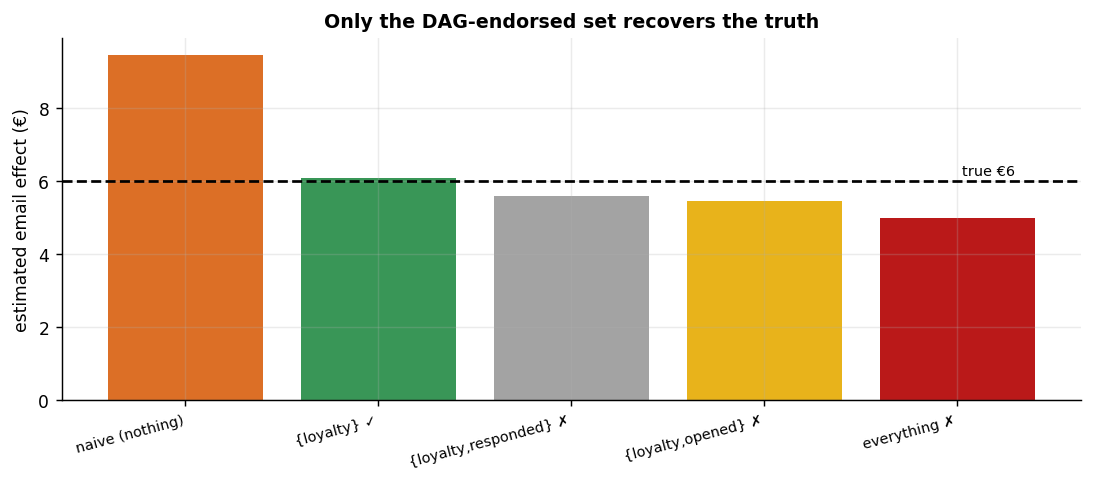

In [5]:
def ols_effect(controls):
    X = np.column_stack([np.ones(len(df)), df["email"].values] + [df[c].values for c in controls])
    return np.linalg.lstsq(X, df["spend"].values, rcond=None)[0][1]

choices = {
    "naive (nothing)": [], "{loyalty} ✓": ["loyalty"],
    "{loyalty,responded} ✗": ["loyalty","responded"],
    "{loyalty,opened} ✗": ["loyalty","opened_email"],
    "everything ✗": ["loyalty","responded","opened_email"],
}
ests = {k: ols_effect(v) for k, v in choices.items()}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(ests)), list(ests.values()), color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(ests))); ax.set_xticklabels(list(ests.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("estimated email effect (€)"); ax.set_title("Only the DAG-endorsed set recovers the truth")
fig.tight_layout()
for k, v in ests.items(): print(f"{k:26s} €{v:5.2f}   (error {v-true_ate:+.2f})")

## 6 · Decide, in euros — with a robustness statement

The value here is a **defensible spec** we can explain to a skeptic: *here's why we controlled for
loyalty, and here's why we did NOT control for opens/responses.* But identification is untestable,
so we bound the residual risk: how strong would an *unobserved* confounder have to be to overturn
the conclusion? `pathmc.sensitivity` gives the tipping surface; the **E-value** summarises it as a
single interpretable number.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_spend, beta_spend, sigma_email, beta_email, beta_responded, beta_opened_email, sigma_responded, sigma_opened_email]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Observed adjusted ATE €6.07 (true €6.0)  ·  E-value ≈ 3.29
An unmeasured confounder would need ~3.3× association with BOTH email and spend to
explain the effect away. Ask the domain expert whether anything that strong is plausible.


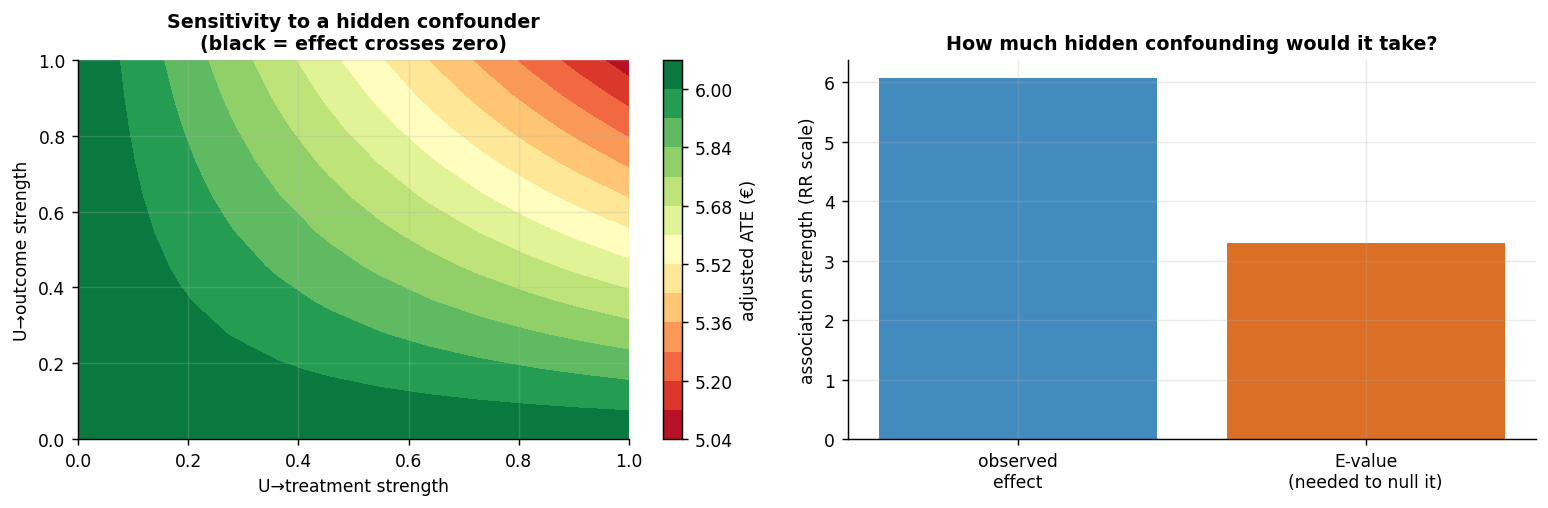

In [6]:
m.fit(random_seed=SEED, progressbar=False, **FIT)
sens = m.sensitivity("spend", "email", n_grid=12)
adj = np.asarray(sens.adjusted_ate_mean); COSTLINE = 0.0
evalue = metrics.e_value(float(sens.observed_ate), cost=COSTLINE, sd=float(df["spend"].std()))
print(f"Observed adjusted ATE €{float(sens.observed_ate):.2f} (true €{true_ate:.1f})  ·  "
      f"E-value ≈ {evalue:.2f}")

g, d = np.meshgrid(sens.gamma_values, sens.delta_values, indexing="ij")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cs = ax[0].contourf(g, d, adj, levels=12, cmap="RdYlGn"); ax[0].contour(g, d, adj, levels=[0], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[0], label="adjusted ATE (€)")
ax[0].set_xlabel("U→treatment strength"); ax[0].set_ylabel("U→outcome strength")
ax[0].set_title("Sensitivity to a hidden confounder\n(black = effect crosses zero)")
# E-value intuition bar
ax[1].bar(["observed\neffect","E-value\n(needed to null it)"], [abs(float(sens.observed_ate)), evalue],
          color=[plots.BLUE, plots.ORANGE], alpha=0.9)
ax[1].set_title("How much hidden confounding would it take?"); ax[1].set_ylabel("association strength (RR scale)")
fig.tight_layout()
print(f"An unmeasured confounder would need ~{evalue:.1f}× association with BOTH email and spend to\n"
      f"explain the effect away. Ask the domain expert whether anything that strong is plausible.")

## 7 · Caveats

- **The graph is an assumption.** `pathmc` gives the correct set *for the DAG you drew*. A missing
  or reversed edge changes the advice — the DAG must encode defensible domain knowledge.
- **Colliders hide in "obvious" controls.** "engaged", "responded", "opened", "clicked" are almost
  always post-treatment; excluding them feels wrong to practitioners and is exactly right.
- **Front-door as a fallback.** If a T–Y confounder is genuinely unmeasured but a fully-mediating
  measured variable exists, the front-door adjustment can still identify the effect — a tool to
  keep in reserve.
- **Sensitivity ≠ proof.** A high E-value means "robust to plausible hidden confounding," not
  "unconfounded." Pair it with the expert's judgement about what could be missing.
